In [ ]:
from rich.jupyter import display
%load_ext autoreload
%autoreload 2

In [ ]:
import torch
import matplotlib.pyplot as plt
import cv2
from image_utils import ImageUtils
from dino_detector import DinoDetector
from clip_classifier import ClipClassifier
from core.models import RegionPrompt
from image_utils import ImageUtils

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
GROUNDING_PROMPT = (
    "food, meal, cooked food, dish, plate, bowl, wooden plate, ceramic plate, cup"
)
FOOD_PROMPTS = ["food", "meal", "cooked food"]
CONTAINER_PROMPTS = ["plate", "bowl", "dish", "wooden plate", "ceramic plate"]

BOX_THRESHOLD = 0.30
TEXT_THRESHOLD = 0.30

# sam
SAM_CHECKPOINT = "checkpoints/sam_vit_b_01ec64.pth"
SAM_MODEL_TYPE = "vit_b"

In [ ]:
from loaders import load_openclip, load_grounding_dino, load_sam, load_depth_anything_v2

# load checkpoints
clip_model, preprocess, tokenizer = load_openclip(device=DEVICE)
dino_model = load_grounding_dino()
sam_predictor = load_sam(SAM_CHECKPOINT, SAM_MODEL_TYPE, device=DEVICE)
depth_anything_model = load_depth_anything_v2(device=DEVICE)

# create objects
dino_detector = DinoDetector(
    device=DEVICE,
    model=dino_model
)

In [11]:
# image
image_path = "photos/wood_dish_1.png"
image_path = "photos/out_screen1.png"
image_path = "photos/ok_light_2.png"
# image_path = "photos/bad_light_1.png"
# image_path = "photos/good_light_1.png"
# image_path = "photos/bad_light_1.png"

# detect objects
image_source, image, boxes, phrases = dino_detector.detect_boxes(
    image_path,
    grounding_prompt=GROUNDING_PROMPT,
    box_threshold=BOX_THRESHOLD,
    text_threshold=TEXT_THRESHOLD,
)

# ImageUtils.display_bounding_boxes(image_source, boxes)
regions: list[RegionPrompt] = []
for box, phrase in zip(boxes, phrases):
    region = RegionPrompt(box=box, label=phrase)
    regions.append(region)

pil_img = ImageUtils.convert_img_source_to_pil(image_source)


In [12]:
from sam_segmenter import SamSegmenter

sam_segmenter = SamSegmenter(predictor=sam_predictor, device=DEVICE)
regions_with_masks = sam_segmenter.segment(image=ImageUtils.pil_to_numpy(pil_img), regions=regions)

# ImageUtils.display_regions_with_masks(regions_with_masks)

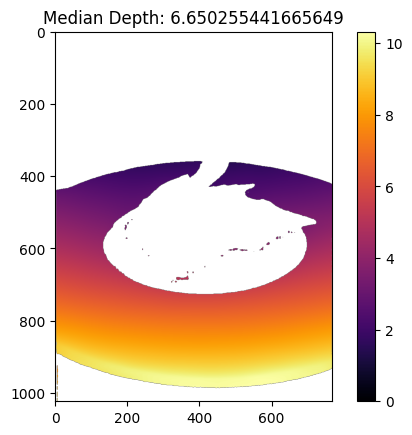

In [13]:
from core.depth import Depth
import numpy as np

depth = depth_anything_model.infer_image(raw_image=image_source, input_size=618)
dmin = np.nanmin(depth)
dmax = np.nanmax(depth)

# full image (scalar)
# ImageUtils.show_depth(
#     depth,
#     title="Depth Anything V2",
#     vmin=dmin,
#     vmax=dmax,
#     cmap="inferno"
# )

# masked regions (scalar)
# for region in regions_with_masks:
#     ImageUtils.show_mask_depth(
#         mask=region.mask,
#         depth=depth,
#         vmin=dmin,
#         vmax=dmax,
#         title=region.label
#     )

norm_depth = Depth.normalize_depth(depth, vmin=dmin, vmax=dmax)
main_dish = Depth.compute_main_dish(depth, regions_with_masks)

ImageUtils.show_mask_depth(
        mask=main_dish.mask,
        image_source_depth=depth,
        vmin=dmin,
        vmax=dmax,
        title=main_dish.label
)


In [ ]:
foods, plates = [], []
for item, mask in zip(kept, masks):
    if item["label"] == "food":
        foods.append({"box": item["box"], "mask": mask})
    else:
        plates.append({"box": item["box"], "mask": mask})

# display food and labels
for f in foods:
    plt.imshow(f["mask"])
    plt.title("food")
    plt.show()
#
for plate in plates:
    plt.imshow(plate["mask"])
    plt.title("plate")
    plt.show()